In [1]:
import os, cv2, torch
from torch.utils.data import Dataset

class LOLDataset(Dataset):
    def __init__(self, low_dir, high_dir, size=256):
        self.low_paths = sorted([os.path.join(low_dir, f) for f in os.listdir(low_dir)])
        self.high_paths = sorted([os.path.join(high_dir, f) for f in os.listdir(high_dir)])
        self.size = size

    def __len__(self):
        return len(self.low_paths)

    def __getitem__(self, idx):
        low = cv2.imread(self.low_paths[idx])
        high = cv2.imread(self.high_paths[idx])

        low = cv2.cvtColor(low, cv2.COLOR_BGR2RGB)
        high = cv2.cvtColor(high, cv2.COLOR_BGR2RGB)

        low = cv2.resize(low, (256,256))
        high = cv2.resize(high, (256,256))

        low = torch.from_numpy(low).float().permute(2,0,1)/255.0
        high = torch.from_numpy(high).float().permute(2,0,1)/255.0

        return low, high

In [2]:
low_path = "/content/lol_dataset/our485/low"
high_path = "/content/lol_dataset/our485/high"

In [3]:
from torch.utils.data import DataLoader
dataset = LOLDataset(low_path, high_path)
loader = DataLoader(dataset, batch_size=1, shuffle=True)

In [4]:
import torch
from RetinexFormer_arch import RetinexFormer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = RetinexFormer(
    n_feat=64,
    stage=2
).to(device)

criterion = torch.nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
epochs = 40
'''
loader = DataLoader(dataset, batch_size=1, shuffle=True)
model = RetinexFormer(
    n_feat=64,
    stage=2
).to(device)
'''

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for low, high in loader:
        low = low.to(device)
        high = high.to(device)

        output = model(low)

        loss = torch.nn.functional.l1_loss(output, high)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss / len(loader)}")

    torch.save(model.state_dict(), f"/content/retinex_{epoch+1}.pth")

Epoch 1, Loss: 0.08359331484000708


In [ ]:
'''
L1 loss:
Epoch 1, Loss: 0.08258171100937521
Epoch 2, Loss: 0.08018972191229924
Epoch 3, Loss: 0.08089847349628959
Epoch 4, Loss: 0.07999746040969165
Epoch 5, Loss: 0.08063967153045934
Epoch 6, Loss: 0.08005257137503821
Epoch 7, Loss: 0.07934113090339395
Epoch 8, Loss: 0.07879831197181927
Epoch 9, Loss: 0.07808027670325078
Epoch 10, Loss: 0.07956592802380778
Epoch 11, Loss: 0.07840263818957142
Epoch 12, Loss: 0.0785360976131921
Epoch 13, Loss: 0.07656378237165741
Epoch 14, Loss: 0.0791165148781747
Epoch 15, Loss: 0.07711469038130389
Epoch 16, Loss: 0.07723773242041622
Epoch 17, Loss: 0.07886485791544325
Epoch 18, Loss: 0.07648502864020387
Epoch 19, Loss: 0.0776973869651556
Epoch 20, Loss: 0.07551479236290012

retinex_1.pth -> Loss: 0.08359331484000708

'''

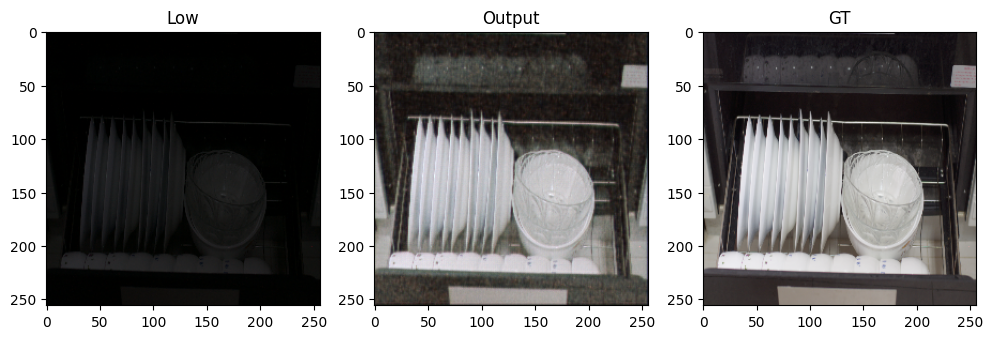

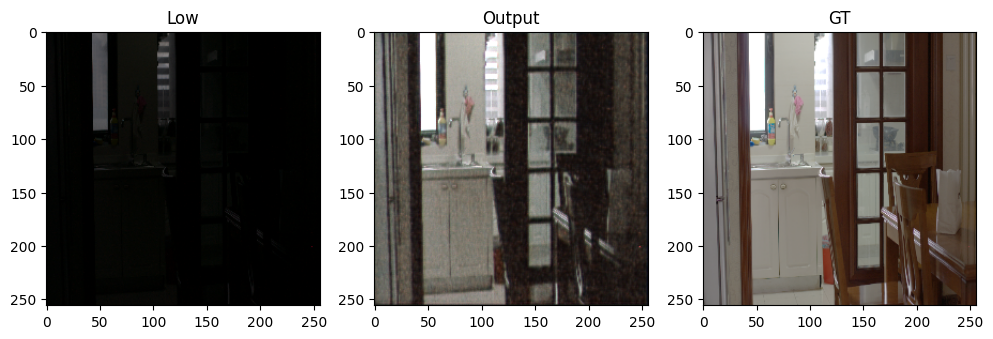

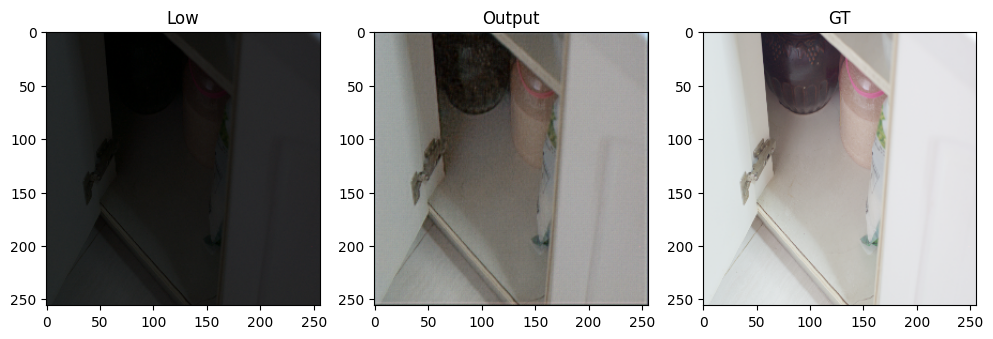

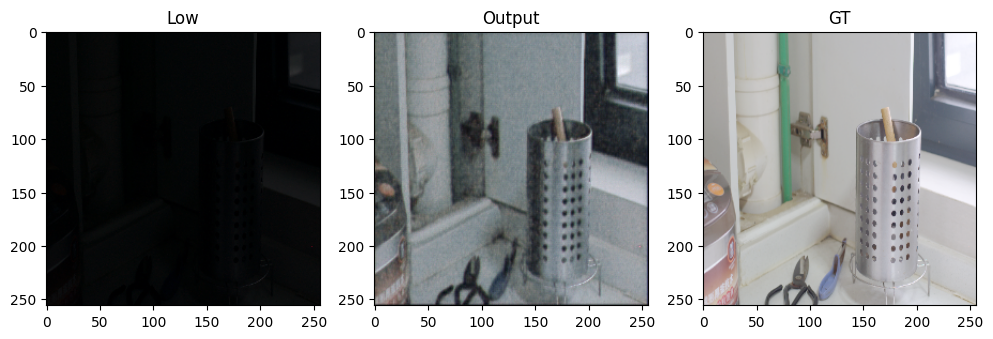

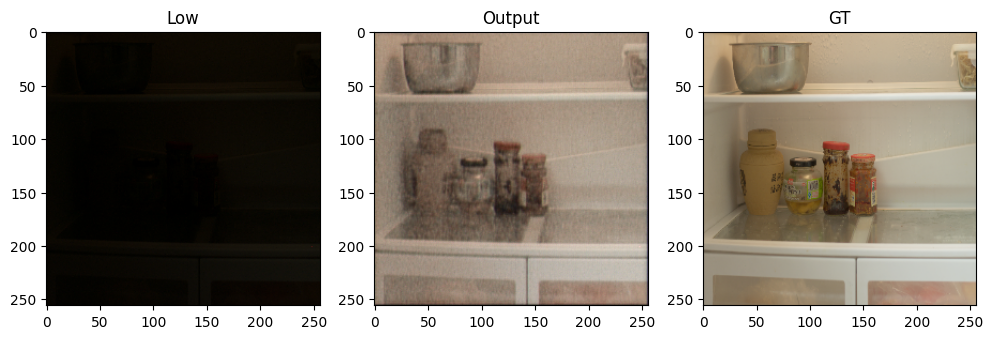

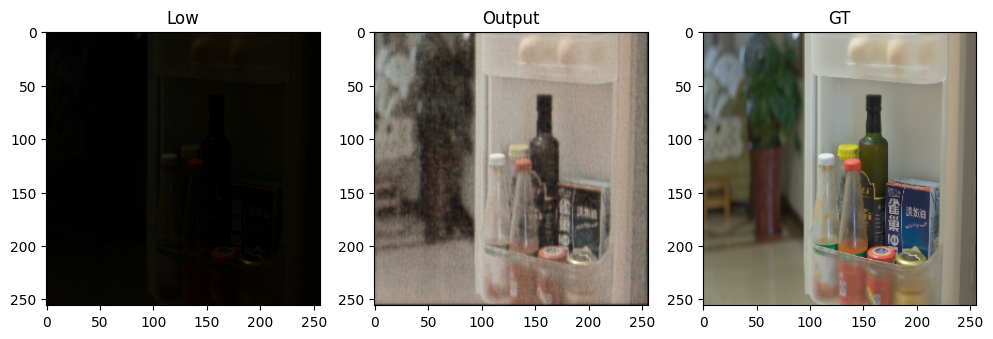

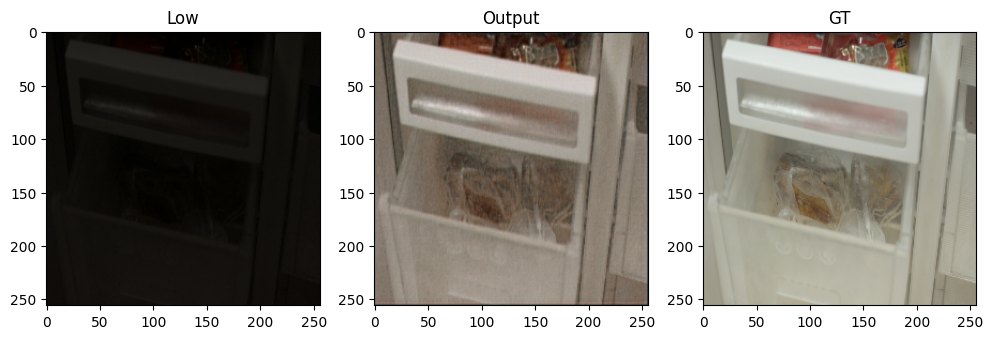

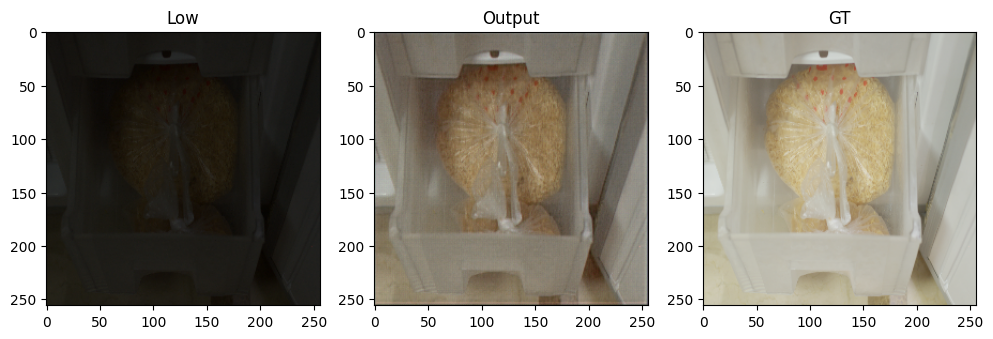

In [12]:
#l1 Loss result

import matplotlib.pyplot as plt

model.eval()
for i in range(1,30,4):
  low, high = dataset[i]
  low_in = low.unsqueeze(0).to(device)

  with torch.no_grad():
      out = model(low_in)

  low_img = low.permute(1,2,0).numpy()
  out_img = out.squeeze().permute(1,2,0).cpu().numpy()
  high_img = high.permute(1,2,0).numpy()

  plt.figure(figsize=(12,4))

  plt.subplot(1,3,1)
  plt.title("Low")
  plt.imshow(low_img)

  plt.subplot(1,3,2)
  plt.title("Output")
  plt.imshow(out_img)

  plt.subplot(1,3,3)
  plt.title("GT")
  plt.imshow(high_img)

  plt.show()

In [15]:
# model enhance_retinex_1 -> n_feat=64, stage=2
import os
import cv2
import torch
import numpy as np
from RetinexFormer_arch import RetinexFormer

# ---------------- CONFIG ---------------- #
MODEL_PATH = "retinex_1.pth"       # path to your trained model
INPUT_DIR = "input_images"       # folder with input images
OUTPUT_DIR = "results_1"           # folder to save outputs

PATCH_SIZE = 128
STRIDE = 32  # overlap for smooth blending

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------- LOAD MODEL ---------------- #
def load_model():
    model = RetinexFormer(n_feat=64, stage=2)  # match training config
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()
    return model

# ---------------- PATCH INFERENCE ---------------- #
def enhance_image(model, img):
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape
    img = img.astype(np.float32) / 255.0

    output = np.zeros((h, w, 3), dtype=np.float32)
    weight = np.zeros((h, w, 3), dtype=np.float32)

    # create smooth patch weight (Hann window)
    patch_weight_1d = np.hanning(PATCH_SIZE)
    patch_weight = np.outer(patch_weight_1d, patch_weight_1d)
    patch_weight = np.expand_dims(patch_weight, axis=2)  # shape (PATCH_SIZE, PATCH_SIZE, 1)

    for i in range(0, h, STRIDE):
        for j in range(0, w, STRIDE):
            patch = img[i:i+PATCH_SIZE, j:j+PATCH_SIZE]
            ph, pw = patch.shape[:2]

            # pad if needed
            if ph < PATCH_SIZE or pw < PATCH_SIZE:
                pad = np.zeros((PATCH_SIZE, PATCH_SIZE, 3), dtype=np.float32)
                pad[:ph, :pw] = patch
                patch = pad

            # to tensor
            patch_tensor = torch.from_numpy(patch).permute(2,0,1).unsqueeze(0).to(DEVICE)

            with torch.no_grad():
                out = model(patch_tensor)

            out = out.squeeze().permute(1,2,0).cpu().numpy()
            out = np.clip(out, 0, 1)
            out = out[:ph, :pw]

            # apply smooth weight
            w_patch = patch_weight[:ph, :pw]
            output[i:i+ph, j:j+pw] += out * w_patch
            weight[i:i+ph, j:j+pw] += w_patch

    # normalize overlapping areas
    output = output / (weight + 1e-8)  # prevent divide by zero
    output = np.clip(output, 0, 1)
    output = (output * 255).astype(np.uint8)
    output = cv2.cvtColor(output, cv2.COLOR_RGB2BGR)

    return output

# ---------------- MAIN ---------------- #
def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    model = load_model()

    for img_name in os.listdir(INPUT_DIR):
        input_path = os.path.join(INPUT_DIR, img_name)
        output_path = os.path.join(OUTPUT_DIR, img_name)

        img = cv2.imread(input_path)
        if img is None:
            print(f"Skipping {img_name}")
            continue

        enhanced = enhance_image(model, img)
        cv2.imwrite(output_path, enhanced)
        print(f"Processed: {img_name}")

    print("Done. Check results folder.")

if __name__ == "__main__":
    main()

/tmp/ipykernel_17719/4110062349.py:67: RuntimeWarning: invalid value encountered in divide
  output = output / weight
/tmp/ipykernel_17719/4110062349.py:69: RuntimeWarning: invalid value encountered in cast
  output = (output * 255).astype(np.uint8)


Processed: textq1.jpg
Processed: test4.jpg
Processed: testq2.jpg
Processed: testq3.jpg
Processed: test2.jpg
Processed: test3.jpg
Processed: test1.jpg
Done. Check results folder.


In [11]:
# model enhance_retinex_0 -> n_feat=16, stage=1
import os
import cv2
import torch
import numpy as np
from RetinexFormer_arch import RetinexFormer

# ---------------- CONFIG ---------------- #
MODEL_PATH = "retinex_0.pth"       # path to your trained model
INPUT_DIR = "input_images"       # folder with input images
OUTPUT_DIR = "results_0"           # folder to save outputs

PATCH_SIZE = 128
STRIDE = 32  # overlap for smooth blending

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------- LOAD MODEL ---------------- #
def load_model():
    model = RetinexFormer(n_feat=16, stage=1)  # match training config
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()
    return model

# ---------------- PATCH INFERENCE ---------------- #
def enhance_image(model, img):
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape
    img = img.astype(np.float32) / 255.0

    output = np.zeros((h, w, 3), dtype=np.float32)
    weight = np.zeros((h, w, 3), dtype=np.float32)

    # create smooth patch weight (Hann window)
    patch_weight_1d = np.hanning(PATCH_SIZE)
    patch_weight = np.outer(patch_weight_1d, patch_weight_1d)
    patch_weight = np.expand_dims(patch_weight, axis=2)  # shape (PATCH_SIZE, PATCH_SIZE, 1)

    for i in range(0, h, STRIDE):
        for j in range(0, w, STRIDE):
            patch = img[i:i+PATCH_SIZE, j:j+PATCH_SIZE]
            ph, pw = patch.shape[:2]

            # pad if needed
            if ph < PATCH_SIZE or pw < PATCH_SIZE:
                pad = np.zeros((PATCH_SIZE, PATCH_SIZE, 3), dtype=np.float32)
                pad[:ph, :pw] = patch
                patch = pad

            # to tensor
            patch_tensor = torch.from_numpy(patch).permute(2,0,1).unsqueeze(0).to(DEVICE)

            with torch.no_grad():
                out = model(patch_tensor)

            out = out.squeeze().permute(1,2,0).cpu().numpy()
            out = np.clip(out, 0, 1)
            out = out[:ph, :pw]

            # apply smooth weight
            w_patch = patch_weight[:ph, :pw]
            output[i:i+ph, j:j+pw] += out * w_patch
            weight[i:i+ph, j:j+pw] += w_patch

    # normalize overlapping areas
    output = output / (weight + 1e-8)  # prevent divide by zero
    output = np.clip(output, 0, 1)
    output = (output * 255).astype(np.uint8)

    output = cv2.cvtColor(output, cv2.COLOR_RGB2BGR)

    return output

# ---------------- MAIN ---------------- #
def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    model = load_model()

    for img_name in os.listdir(INPUT_DIR):
        input_path = os.path.join(INPUT_DIR, img_name)
        output_path = os.path.join(OUTPUT_DIR, img_name)

        img = cv2.imread(input_path)
        if img is None:
            print(f"Skipping {img_name}")
            continue

        enhanced = enhance_image(model, img)
        cv2.imwrite(output_path, enhanced)
        print(f"Processed: {img_name}")

    print("Done. Check results folder.")

if __name__ == "__main__":
    main()

/tmp/ipykernel_17719/1533448564.py:67: RuntimeWarning: invalid value encountered in divide
  output = output / weight
/tmp/ipykernel_17719/1533448564.py:69: RuntimeWarning: invalid value encountered in cast
  output = (output * 255).astype(np.uint8)


Processed: textq1.jpg
Processed: test4.jpg
Processed: testq2.jpg
Processed: testq3.jpg
Processed: test2.jpg
Processed: test3.jpg
Processed: test1.jpg
Done. Check results folder.
